# Benchmark: Reproducing SI WIMP limits from XENONnT & LZ

In [1]:
import os
import diamx
from diamx.model import DiamxModel
from diamx.utils import generate_bin_array
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

diamx_dir = os.path.dirname(diamx.__file__)

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="appletree.config")
warnings.filterwarnings("ignore", category=UserWarning, module="appletree.component")

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles


In [87]:
import matplotlib

plt.style.use("seaborn-v0_8-colorblind")
plt.rcParams.update(
    {
        "figure.figsize": (6.4, 4.8),
        "figure.dpi": 600,
        "font.family": "serif",
        "font.size": 12,
        # 'figure.dpi': 300,
        "lines.linewidth": 2.0,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.major.size": 8,
        "xtick.minor.size": 4,
        "ytick.major.size": 8,
        "ytick.minor.size": 4,
        "xtick.major.width": 1,
        "xtick.minor.width": 0.7,
        "ytick.major.width": 1,
        "ytick.minor.width": 0.7,
        "xtick.direction": "in",
        "ytick.direction": "in",
        # 'legend.loc': 'upper center',
        # 'legend.bbox_to_anchor': (0.5, 1.05),
        # 'legend.ncol': 3,
        "legend.fancybox": True,  # if True, use a rounded box for the
        # legend background, else a rectangle
        "legend.fontsize": 12,
    }
)

## 0. Generate Input WIMP spectrum

Using package wimprates

In [2]:
import wimprates

energies = np.linspace(0.01, 100, 200)
wimp_masses = (
    list(range(6, 130, 2)) + list(range(130, 400, 10)) + [400, 500, 600, 800, 1000]
)
wimp_masses += list(range(100, 1000, 50)) + [1000, 2500, 5000, 10000]
wimp_masses = set(wimp_masses)
spectrum_data = np.zeros((len(energies), 2))
spectrum_data[:, 0] = energies
os.makedirs("./diamx_output/spectrum", exist_ok=True)
for wimp_mass in wimp_masses:
    spectrum_csv_fpath = os.path.join(
        "./diamx_output", "spectrum", f"wimp_{wimp_mass}GeV.csv"
    )
    spectrum_data[:, 1] = wimprates.rate_wimp_std(
        energies, mw=wimp_mass, sigma_nucleon=1e-44
    )
    np.savetxt(spectrum_csv_fpath, spectrum_data, delimiter=",")

/home/mhliu/miniconda3/envs/xenon/lib/python3.10/site-packages/wimprates/__init__.py:6: UserWarning: Default WIMP parameters are changed in accordance with https://arxiv.org/abs/2105.00599 (github.com/JelleAalbers/wimprates/pull/14)
  warnings.warn(


In [108]:
def plot_contours_and_pies(context, plot_config, file_base="../diamx/data"):
    """
    Plots the contours for the given plot configuration.

    Parameters
    ----------
    context : DiamxModel
        The Diamx model context.
    plot_config : dict
        The plot configuration dictionary containing the experiment name and specifications for each plot item.
        It should have the following structure:
        {
            "experiment_name": "experiment_name",
            "signal_parameter_value": 1000, # For the best_fit model
            "content_specs": [
                # For each component to plot
                {
                    "type": "bkg", # or "shaped_bkg" or "best_fit_bkg" or "signal"
                    "plot_contour_diamx": True,
                    "plot_contour_literature": True,
                    "include_in_pie_charts": True,
                    "component_name": "background_name",
                    "shape_parameter_value": 0.5, # Only for shaped_bkg
                    "color": "blue",
                    "one_sigma_contour_fname": "one_sigma_contour.csv",
                    "two_sigma_contour_fname": "two_sigma_contour.csv",
                    "log10_contour": True,
                    "label": "Label for the plot item"
                },
                ...
            ],
            "fig_specs": {
                "figure_size": [4, 3],
                "axis_names": ["cs1", "cs2"],
                "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
                "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
                "axis_scales": ["linear", "log"],
                "contour_linestyles": ["--", "-"],
                "plot_pie_charts": True,
                "pie_size_min": 2,
                "pie_size_max": 10,
                "pie_axis_width": 0.01,
                "pie_axis_height": 0.01,
                "legend_kwargs": {
                    "loc": "upper center",
                    "bbox_to_anchor": (0.5, 1.05),
                    "ncol": 3,
                }
            },
        }
    file_base : str
        The base directory where the contour files are located.

    Returns
    -------
    None
    This function does not return anything. It generates plots based on the provided configuration.
    """
    fig_specs = plot_config.get(
        "fig_specs",
        {
            "figure_size": [4, 3],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 2,
            "pie_size_max": 10,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
        },
    )
    fig, ax = plt.subplots(1, 1, figsize=fig_specs.get("figure_size", [4, 3]))
    ax.set_xlabel(fig_specs["axis_labels"][0])
    ax.set_ylabel(fig_specs["axis_labels"][1])
    ax.set_xscale(fig_specs["axis_scales"][0])
    ax.set_xlim(fig_specs["axis_limits"][0])
    ax.set_yscale(fig_specs["axis_scales"][1])
    ax.set_ylim(fig_specs["axis_limits"][1])
    experiment_name = plot_config["experiment_name"]
    for plot_item in plot_config["content_specs"]:
        if plot_item.get("plot_contour_diamx", True):
            if plot_item["type"] == "bkg":
                context.plot_bkg_template(
                    experiment_name,
                    plot_item["component_name"],
                    mode=["contour"],
                    contour_kwargs={
                        "colors": [plot_item["color"], plot_item["color"]],
                        "linestyles": fig_specs.get("contour_linestyles", ["--", "-"]),
                    },
                )
            elif plot_item["type"] == "shaped_bkg":
                assert (
                    "shape_parameter_value" in plot_item
                ), "shape_parameter_value must be provided for shaped_bkg"
                context.plot_bkg_template(
                    experiment_name,
                    plot_item["component_name"],
                    shape_parameter_value=plot_item["shape_parameter_value"],
                    mode=["contour"],
                    contour_kwargs={
                        "colors": [plot_item["color"], plot_item["color"]],
                        "linestyles": fig_specs.get("contour_linestyles", ["--", "-"]),
                    },
                )
            elif plot_item["type"] == "best_fit_bkg":
                context.plot_best_fit_bkg_mh(
                    experiment_name,
                    plot_config["signal_parameter_value"],
                    bkg_to_include=plot_item.get("bkg_to_include", None),
                    mode=["contour"],
                    contour_kwargs={
                        "colors": [plot_item["color"], plot_item["color"]],
                        "linestyles": fig_specs.get("contour_linestyles", ["--", "-"]),
                    },
                )
            elif plot_item["type"] == "signal":
                context.plot_signal_template(
                    experiment_name,
                    plot_config["signal_parameter_value"],
                    mode=["contour"],
                    contour_kwargs={
                        "colors": [plot_item["color"], plot_item["color"]],
                        "linestyles": ["--", "-"],
                    },
                )
            else:
                raise ValueError(f"Unknown plot item type: {plot_item['type']}")
        if plot_item.get("plot_contour_literature", True):
            if "one_sigma_contour_fname" in plot_item:
                if isinstance(plot_item["one_sigma_contour_fname"], str):
                    one_sigma_fnames = [plot_item["one_sigma_contour_fname"]]
                else:
                    one_sigma_fnames = plot_item["one_sigma_contour_fname"]
                for one_sigma_fname in one_sigma_fnames:
                    one_sigma_contour = np.loadtxt(
                        os.path.join(file_base, one_sigma_fname), delimiter=","
                    )
                    if plot_item.get("log10_contour", False):
                        ax.fill(
                            one_sigma_contour[:, 0],
                            10 ** one_sigma_contour[:, 1],
                            color=plot_item["color"],
                            alpha=0.2,
                        )
                    else:
                        ax.fill(
                            one_sigma_contour[:, 0],
                            one_sigma_contour[:, 1],
                            color=plot_item["color"],
                            alpha=0.2,
                        )
            if "two_sigma_contour_fname" in plot_item:
                if isinstance(plot_item["two_sigma_contour_fname"], str):
                    two_sigma_fnames = [plot_item["two_sigma_contour_fname"]]
                else:
                    two_sigma_fnames = plot_item["two_sigma_contour_fname"]
                for two_sigma_fname in two_sigma_fnames:
                    two_sigma_contour = np.loadtxt(
                        os.path.join(file_base, two_sigma_fname), delimiter=","
                    )
                    if plot_item.get("log10_contour", False):
                        ax.fill(
                            two_sigma_contour[:, 0],
                            10 ** two_sigma_contour[:, 1],
                            color=plot_item["color"],
                            alpha=0.1,
                        )
                    else:
                        ax.fill(
                            two_sigma_contour[:, 0],
                            two_sigma_contour[:, 1],
                            color=plot_item["color"],
                            alpha=0.1,
                        )
    fig.canvas.draw()  # Render the figure to get the correct transforms
    data_to_figure = ax.transData + fig.transFigure.inverted()

    if fig_specs.get("plot_pie_charts", True):
        data = None
        for experiment_instance in context.experiment_instances:
            if experiment_instance.experiment_name == experiment_name:
                data = experiment_instance.get_data()
                break
        if data is None:
            raise ValueError(f"No data found for experiment {experiment_name}")
        local_pdf_raw = context.get_best_fit_local_pdf(
            experiment_name=experiment_name,
            signal_parameter_value=plot_config["signal_parameter_value"],
            data_points=np.stack(
                (data[fig_specs["axis_names"][0]], data[fig_specs["axis_names"][1]]),
                axis=-1,
            ),
        )
        local_pdf_merged = (
            {}
        )  # Sometimes we need to merge multiple bkg into one in the pie chart
        component_color_map = {}
        best_fit_bkg_component_name = None
        signal_name = None
        for plot_item in plot_config["content_specs"]:
            if not plot_item.get("include_in_pie_charts", True):
                continue
            component_name = plot_item["component_name"]
            component_color_map[component_name] = plot_item["color"]
            if plot_item["type"] in ["bkg", "shaped_bkg"]:
                local_pdf_merged[component_name] = local_pdf_raw[component_name]
            elif plot_item["type"] == "best_fit_bkg":
                if "bkg_to_include" not in plot_item:
                    # If bkg_to_include is not given, we need to sum up all backgrounds except signal
                    # We will treat this case outside this loop
                    assert (
                        best_fit_bkg_component_name is None
                    ), "Only one best_fit_bkg without bkg_to_include is allowed"
                    best_fit_bkg_component_name = component_name
                    continue
                for bkg_name in plot_item["bkg_to_include"]:
                    if component_name in local_pdf_merged:
                        local_pdf_merged[component_name] += local_pdf_raw[bkg_name]
                    else:
                        local_pdf_merged[component_name] = local_pdf_raw[bkg_name]
            elif plot_item["type"] == "signal":
                local_pdf_merged[component_name] = local_pdf_raw[component_name]
                signal_name = component_name
        assert (
            signal_name is not None
        ), "Signal component must be included in the plot_config to draw pie charts"
        # Handle the case where best_fit_bkg includes all backgrounds except signal
        if best_fit_bkg_component_name is not None:
            total_bkg = np.zeros(len(data))
            for key in local_pdf_raw:
                if key != signal_name:
                    total_bkg += local_pdf_raw[key]
            local_pdf_merged[best_fit_bkg_component_name] = total_bkg

        data_points_pie_dtype = [
            (fig_specs["axis_names"][0], float),
            (fig_specs["axis_names"][1], float),
        ]
        for key in local_pdf_merged:
            data_points_pie_dtype.append((f"pdf_{key}", float))
        data_points_pie_dtype.append(("pie_size", float))
        data_points_pie = np.zeros(data.shape, dtype=data_points_pie_dtype)
        data_points_pie[fig_specs["axis_names"][0]] = data[fig_specs["axis_names"][0]]
        data_points_pie[fig_specs["axis_names"][1]] = data[fig_specs["axis_names"][1]]
        for key in local_pdf_merged:
            data_points_pie[f"pdf_{key}"] = local_pdf_merged[key]

        # Determine pie sizes based on signal component
        denom = np.add.reduce([local_pdf_merged[key] for key in local_pdf_merged])
        signal_relative_size = np.divide(
            local_pdf_merged[signal_name],
            denom,
            out=np.zeros_like(denom),
            where=denom > 0,
        )  # Avoid division by zero if the local pdf is all zero
        m = signal_relative_size.max()
        if m > 0:
            signal_relative_size = signal_relative_size / m
            data_points_pie["pie_size"] = fig_specs[
                "pie_size_min"
            ] + signal_relative_size * (
                fig_specs["pie_size_max"] - fig_specs["pie_size_min"]
            )
        else:
            data_points_pie["pie_size"] = fig_specs["pie_size_min"]

        # Order the pie charts by pie size (smallest drawn last)
        data_points_pie = np.sort(data_points_pie, order="pie_size")[::-1]

        for data_point_pie in data_points_pie:
            pie_center = data_to_figure.transform(
                (
                    data_point_pie[fig_specs["axis_names"][0]],
                    data_point_pie[fig_specs["axis_names"][1]],
                )
            )
            ax_pie = fig.add_axes(
                [
                    pie_center[0] - fig_specs["pie_axis_width"] / 2,
                    pie_center[1] - fig_specs["pie_axis_height"] / 2,
                    fig_specs["pie_axis_width"],
                    fig_specs["pie_axis_height"],
                ]
            )
            ax_pie.pie(
                [data_point_pie[f"pdf_{key}"] for key in local_pdf_merged],
                colors=[component_color_map[key] for key in local_pdf_merged],
                radius=data_point_pie["pie_size"],
            )

    legend_handles = [
        Patch(facecolor=plot_item["color"], alpha=1, label=plot_item["label"])
        for plot_item in plot_config["content_specs"]
    ]
    ax.legend(handles=legend_handles, **fig_specs.get("legend_kwargs", {}))

## 1. XENONnT SR0

https://doi.org/10.1103/PhysRevLett.131.041003

Modelling: ER (flat spectrum), neutron, AC

ROI: cs2 > 400PE (cut surface events)

In [67]:
xenonnt_sr0_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_wimp_config_full_roi.json"),
)
xenonnt_sr0_st.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr0_st.generate_templates()

Generating background templates for xenonnt_sr0: 100%|██████████| 4/4 [00:00<00:00, 1706.56it/s]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr0: 100%|██████████| 90/90 [00:00<00:00, 1943.10it/s]


In [4]:
data_points = xenonnt_sr0_st.experiment_instances[0].get_data()
local_pdf = xenonnt_sr0_st.get_best_fit_local_pdf(
    experiment_name="xenonnt_sr0",
    signal_parameter_value=200,
    data_points=np.stack((data_points["cs1"], data_points["cs2"]), axis=-1),
)

True


True


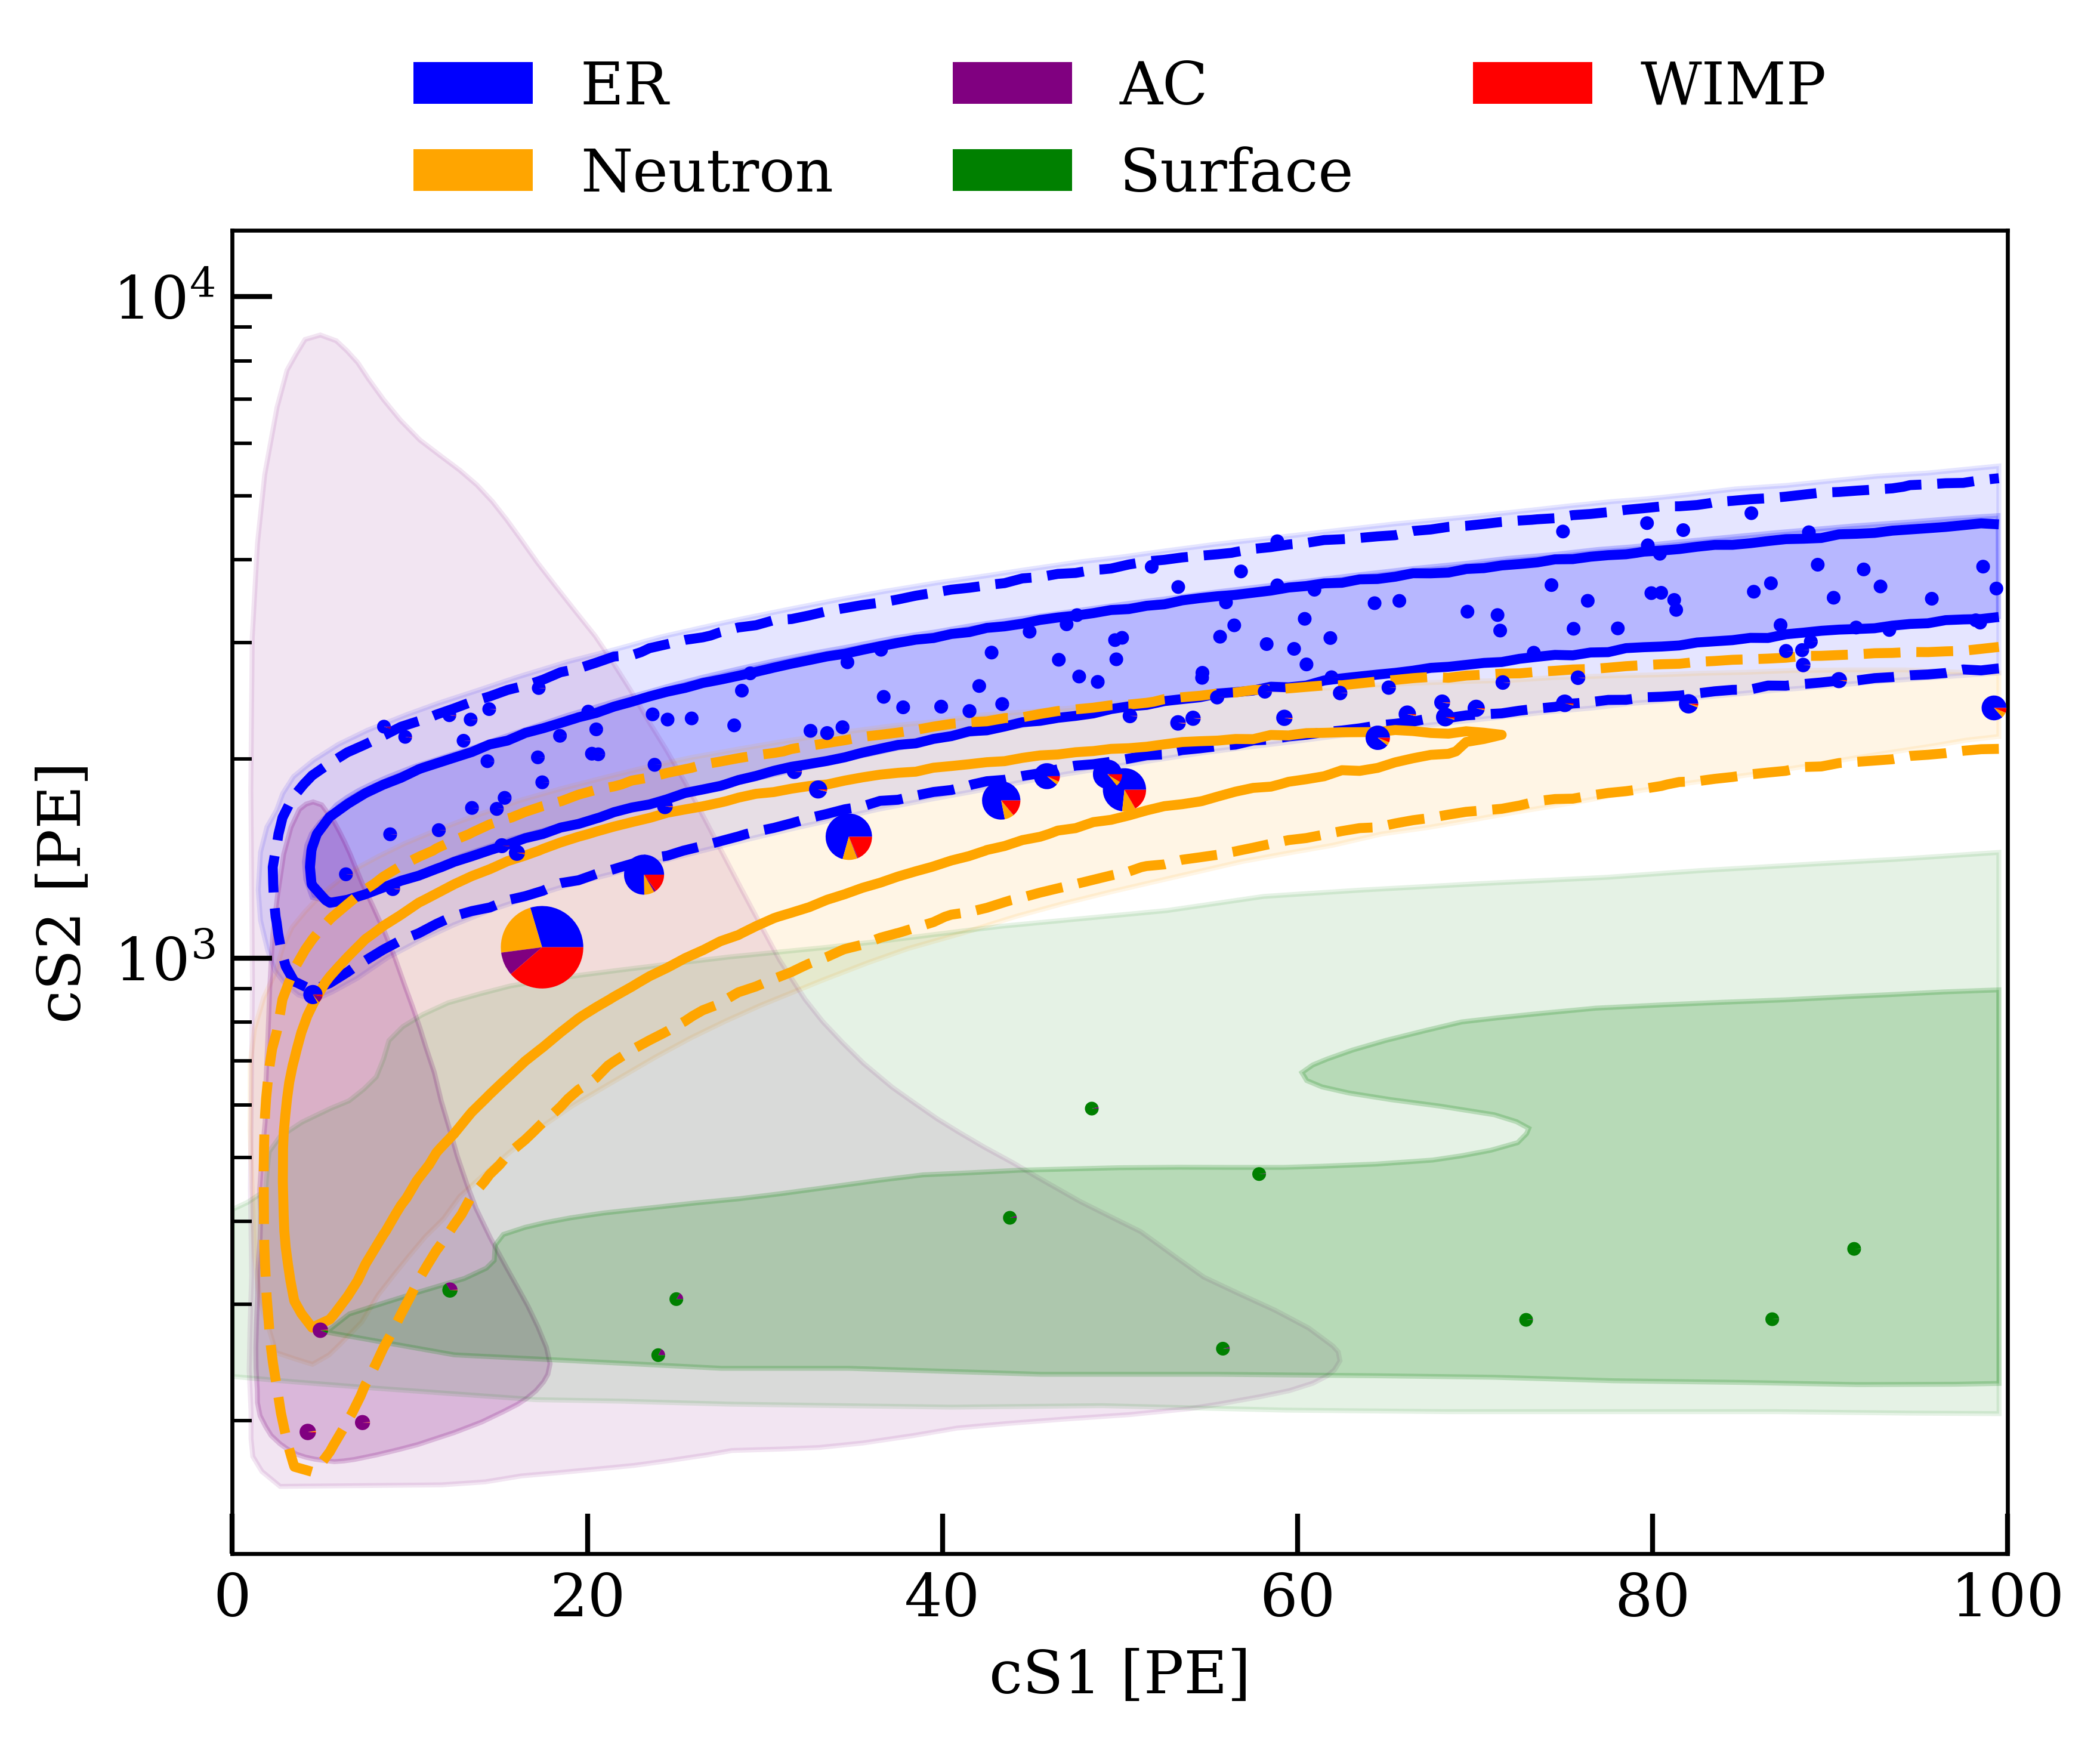

In [132]:
plot_contours_and_pies(
    xenonnt_sr0_st,
    {
        "experiment_name": "xenonnt_sr0",
        "signal_parameter_value": 200,
        "content_specs": [
            {
                "type": "bkg",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "component_name": "er",
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr0_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr0_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "component_name": "neutron",
                "color": "orange",
                "two_sigma_contour_fname": "xenonnt_sr0_neutron_2sigma.csv",
                "log10_contour": False,
                "label": "Neutron",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "component_name": "ac",
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr0_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr0_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "component_name": "surface",
                "color": "green",
                "one_sigma_contour_fname": "xenonnt_sr0_surface_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr0_surface_2sigma.csv",
                "log10_contour": False,
                "label": "Surface",
            },
            {
                "type": "signal",
                "plot_contour_diamx": False,
                "plot_contour_literature": False,
                "component_name": "wimp",
                "color": "red",
                "label": "WIMP",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 6,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.17),
                "ncol": 3,
            },
        },
    },
)
plt.savefig("../plots/xenonnt_sr0_s1c_s2c_contours.png")

In [100]:
xenonnt_sr0_st.print_best_fit(200)

True
xenonnt_sr0
           Nominal   Best fit
er             134   135 ± 12
neutron  1.1 ± 0.5  1.1 ± 0.5
ac       4.3 ± 0.9  4.3 ± 0.8
surface     14 ± 3     12 ± 2
Signal best fit: 1.5955422333236302



Running inference: 100%|██████████| 90/90 [01:08<00:00,  1.31it/s]


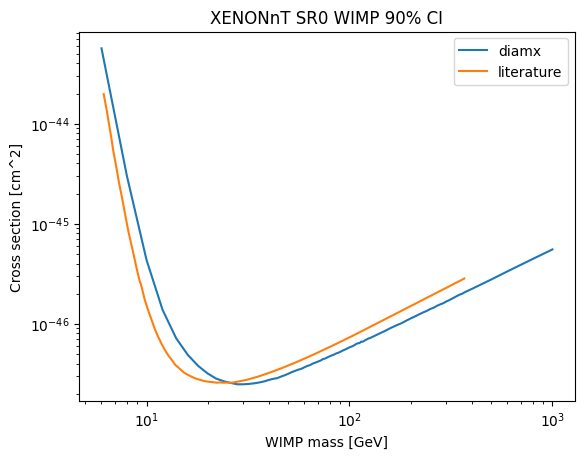

In [7]:
# Reproducing Fig. 4 (upper limit)
xenonnt_sr0_st.run_inference(output_file_name="xenonnt_sr0_wimp_ci_full_roi.csv")
ci = np.loadtxt("./diamx_output/xenonnt_sr0_wimp_ci_full_roi.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr0_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0 WIMP 90% CI")
plt.savefig("../plots/xenonnt_sr0_wimp_ci_full_roi.png", dpi=600)

Alternatively, use `cS2 > 400PE`:

Generating background templates for xenonnt_sr0: 100%|██████████| 4/4 [00:13<00:00,  3.36s/it]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr0: 100%|██████████| 90/90 [10:46<00:00,  7.18s/it]


xenonnt_sr0
           Nominal   Best fit
er             134   134 ± 12
neutron  1.1 ± 0.5  1.1 ± 0.5
ac               1  0.0 ± 0.7
surface          1  3.0 ± 1.7
Signal best fit: 3.113224527025174



Running inference: 100%|██████████| 90/90 [01:33<00:00,  1.04s/it]


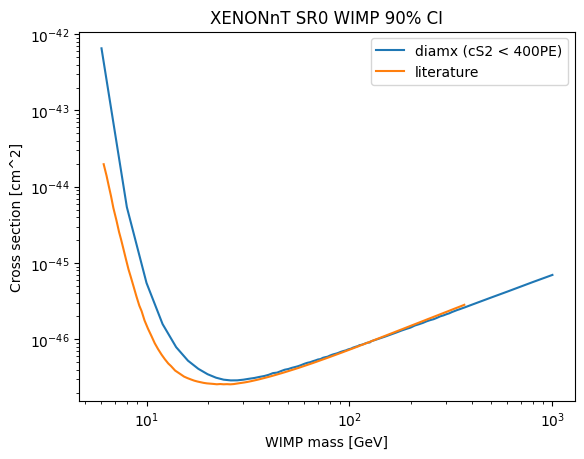

In [8]:
xenonnt_sr0_st_400PE = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_wimp_config.json"),
)
xenonnt_sr0_st_400PE.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr0_st_400PE.generate_templates()
xenonnt_sr0_st_400PE.print_best_fit(200)
xenonnt_sr0_st_400PE.run_inference(output_file_name="xenonnt_sr0_wimp_ci_400PE.csv")
ci_400PE = np.loadtxt("./diamx_output/xenonnt_sr0_wimp_ci_400PE.csv", delimiter=",")
plt.plot(ci_400PE[:, 0], ci_400PE[:, 2] * 1e-44, label="diamx (cS2 < 400PE)")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr0_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0 WIMP 90% CI")
plt.savefig("../plots/xenonnt_sr0_wimp_ci_400PE.png", dpi=600, bbox_inches="tight")

## 2. LZ WS2022

DOI: https://doi.org/10.1103/PhysRevLett.131.041002

Modelling: beta+gamma (flat ER), neutrino (flat ER), 127Xe (5.2keV L-shell with 0.87 Q_L/Q_beta), 124Xe (5.98keV + 10keV), 37Ar (2.82keV)

In [102]:
lz_ws2022_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "lz_ws2022_wimp_config.json"),
)
lz_ws2022_st.register_experiment(diamx.experiments.LZWS2022)
lz_ws2022_st.prepare()
# lz_ws2022_st.generate_templates()

True
True


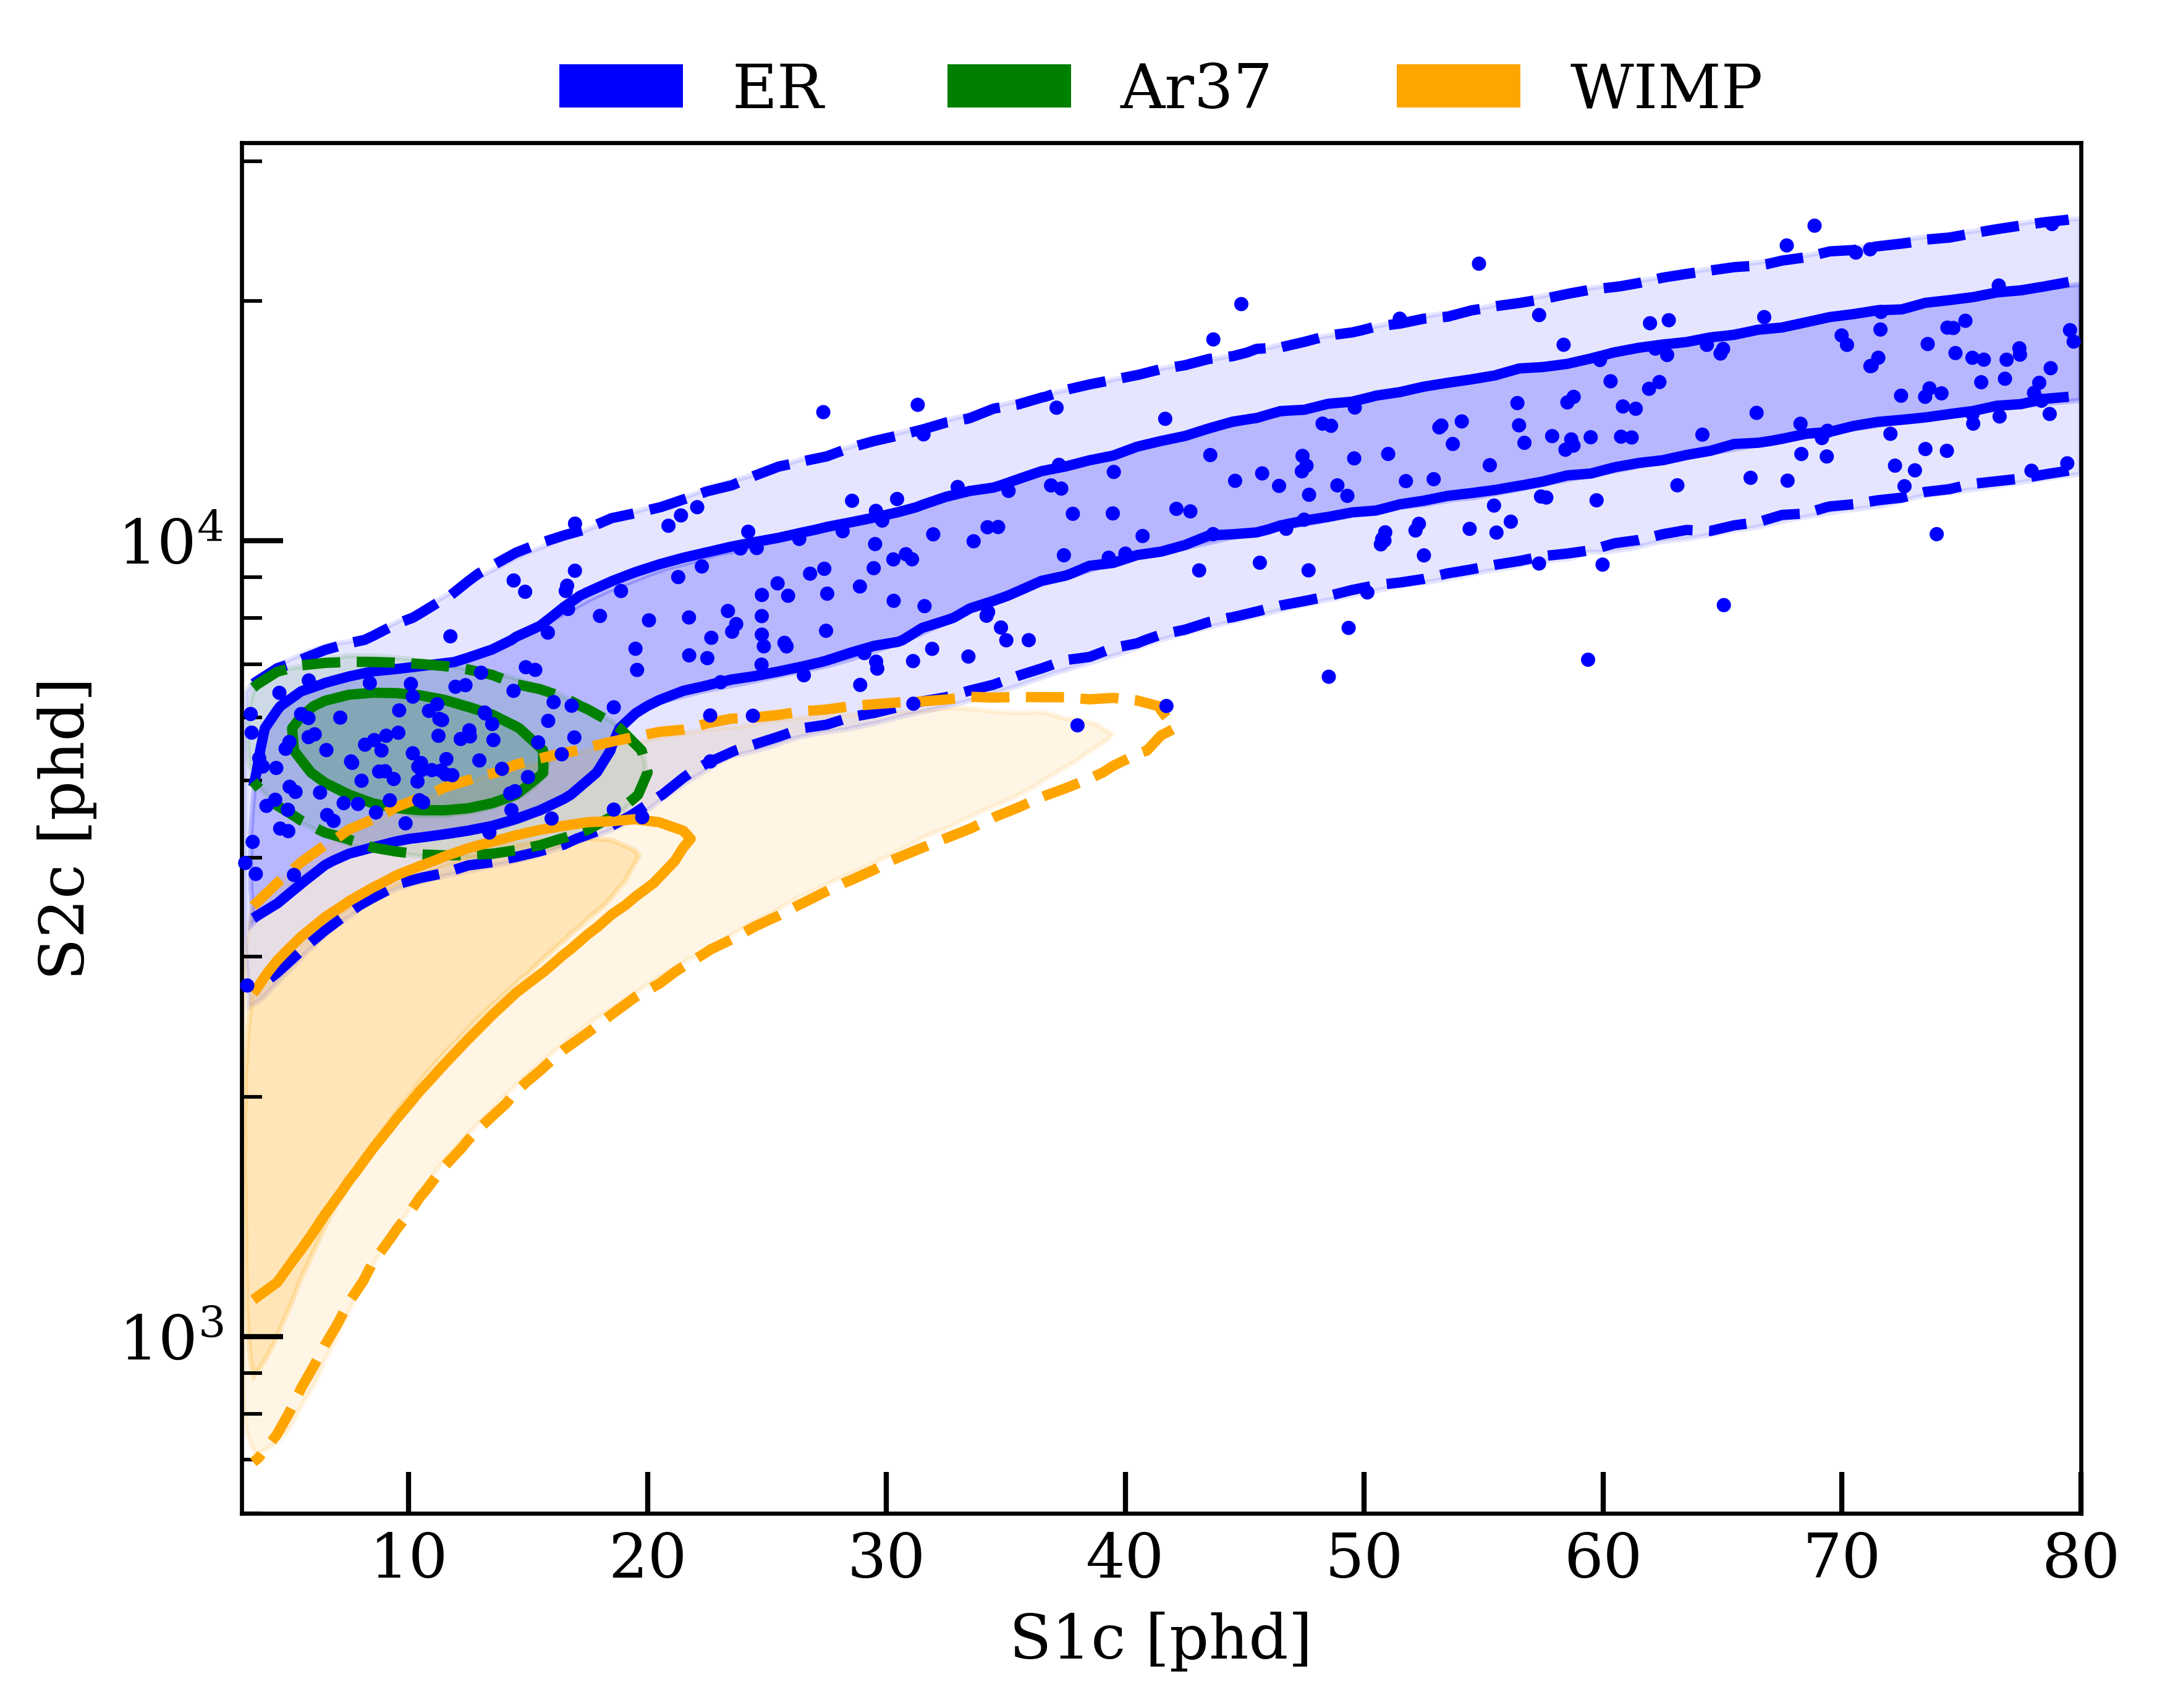

In [131]:
plot_contours_and_pies(
    lz_ws2022_st,
    {
        "experiment_name": "lz_ws2022",
        "signal_parameter_value": 30,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "component_name": "er",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "color": "blue",
                "one_sigma_contour_fname": "lz_ws2022_bkg_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2022_bkg_2sigma.csv",
                "log10_contour": True,
                "bkg_to_include": [
                    "beta",
                    "neutrino",
                    "xe127",
                    "xe124",
                    "xe136",
                    "ar37",
                ],
                "label": "ER",
            },
            {
                "type": "bkg",
                "component_name": "ar37",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "include_in_pie_charts": False,
                "color": "green",
                "one_sigma_contour_fname": "lz_ws2022_ar37_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2022_ar37_2sigma.csv",
                "log10_contour": True,
                "label": "Ar37",
            },
            {
                "type": "signal",
                "component_name": "wimp",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "color": "orange",
                "one_sigma_contour_fname": "lz_ws2022_wimp_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2022_wimp_2sigma.csv",
                "log10_contour": True,
                "label": "WIMP",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["s1c", "s2c"],
            "axis_labels": ["S1c [phd]", "S2c [phd]"],
            "axis_limits": [[3, 80], [600, 10**4.5]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 1,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 3,
            },
        },
    },
)

plt.savefig("../plots/lz_ws2022_s1c_s2c_contours.png", dpi=600, bbox_inches="tight")

In [11]:
lz_ws2022_st.print_best_fit(30, disable_rounding=True, stabilize_fit=False)

lz_ws2022
                           Nominal                                 Best fit
beta                  215.0 ± 36.0  224.46396439845762 ± 16.168874024476867
neutrino                27.1 ± 1.6  27.119061772197366 ± 1.5984858616972573
xe127                    9.2 ± 0.8   9.245741388546795 ± 0.7932706198055915
xe124     5.0 ± 1.3999999999999997   5.314546367178356 ± 1.3755565434540105
xe136                   15.1 ± 2.4   15.142167275185992 ± 2.389461916748272
ar37                          50.0    50.27325466028408 ± 9.081871293651606
Signal best fit: 5.835453178239078e-06



Running inference: 100%|██████████| 67/67 [01:11<00:00,  1.07s/it]


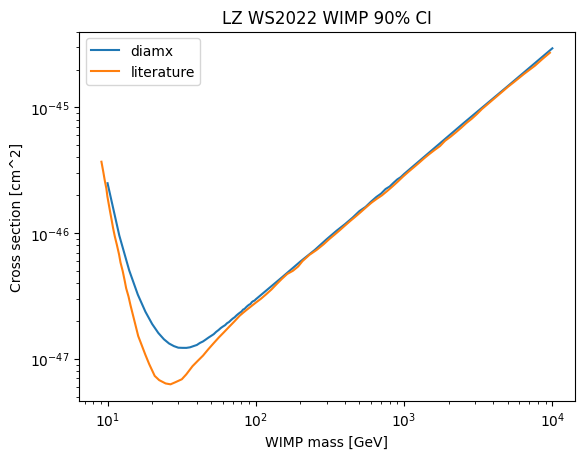

In [12]:
# Reproducing Fig. 5 (upper limit)
lz_ws2022_st.run_inference(output_file_name="lz_ws2022_wimp_ci.csv")
ci = np.loadtxt("./diamx_output/lz_ws2022_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/lz_ws2022_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("LZ WS2022 WIMP 90% CI")
plt.savefig("../plots/lz_ws2022_wimp_ci.png", dpi=600)
# plt.show()

## 3. XENONnT combined SR0 & SR1

arXiv:2502.18005

In [110]:
xenonnt_sr01_st = diamx.Context(
    os.path.join(
        diamx_dir, "..", "config", "xenonnt_sr0_and_1_wimp_config_full_roi.json"
    ),
)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR1a)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR1b)
xenonnt_sr01_st.prepare()
# xenonnt_sr01_st.generate_templates()

True
True
True
True
True
True


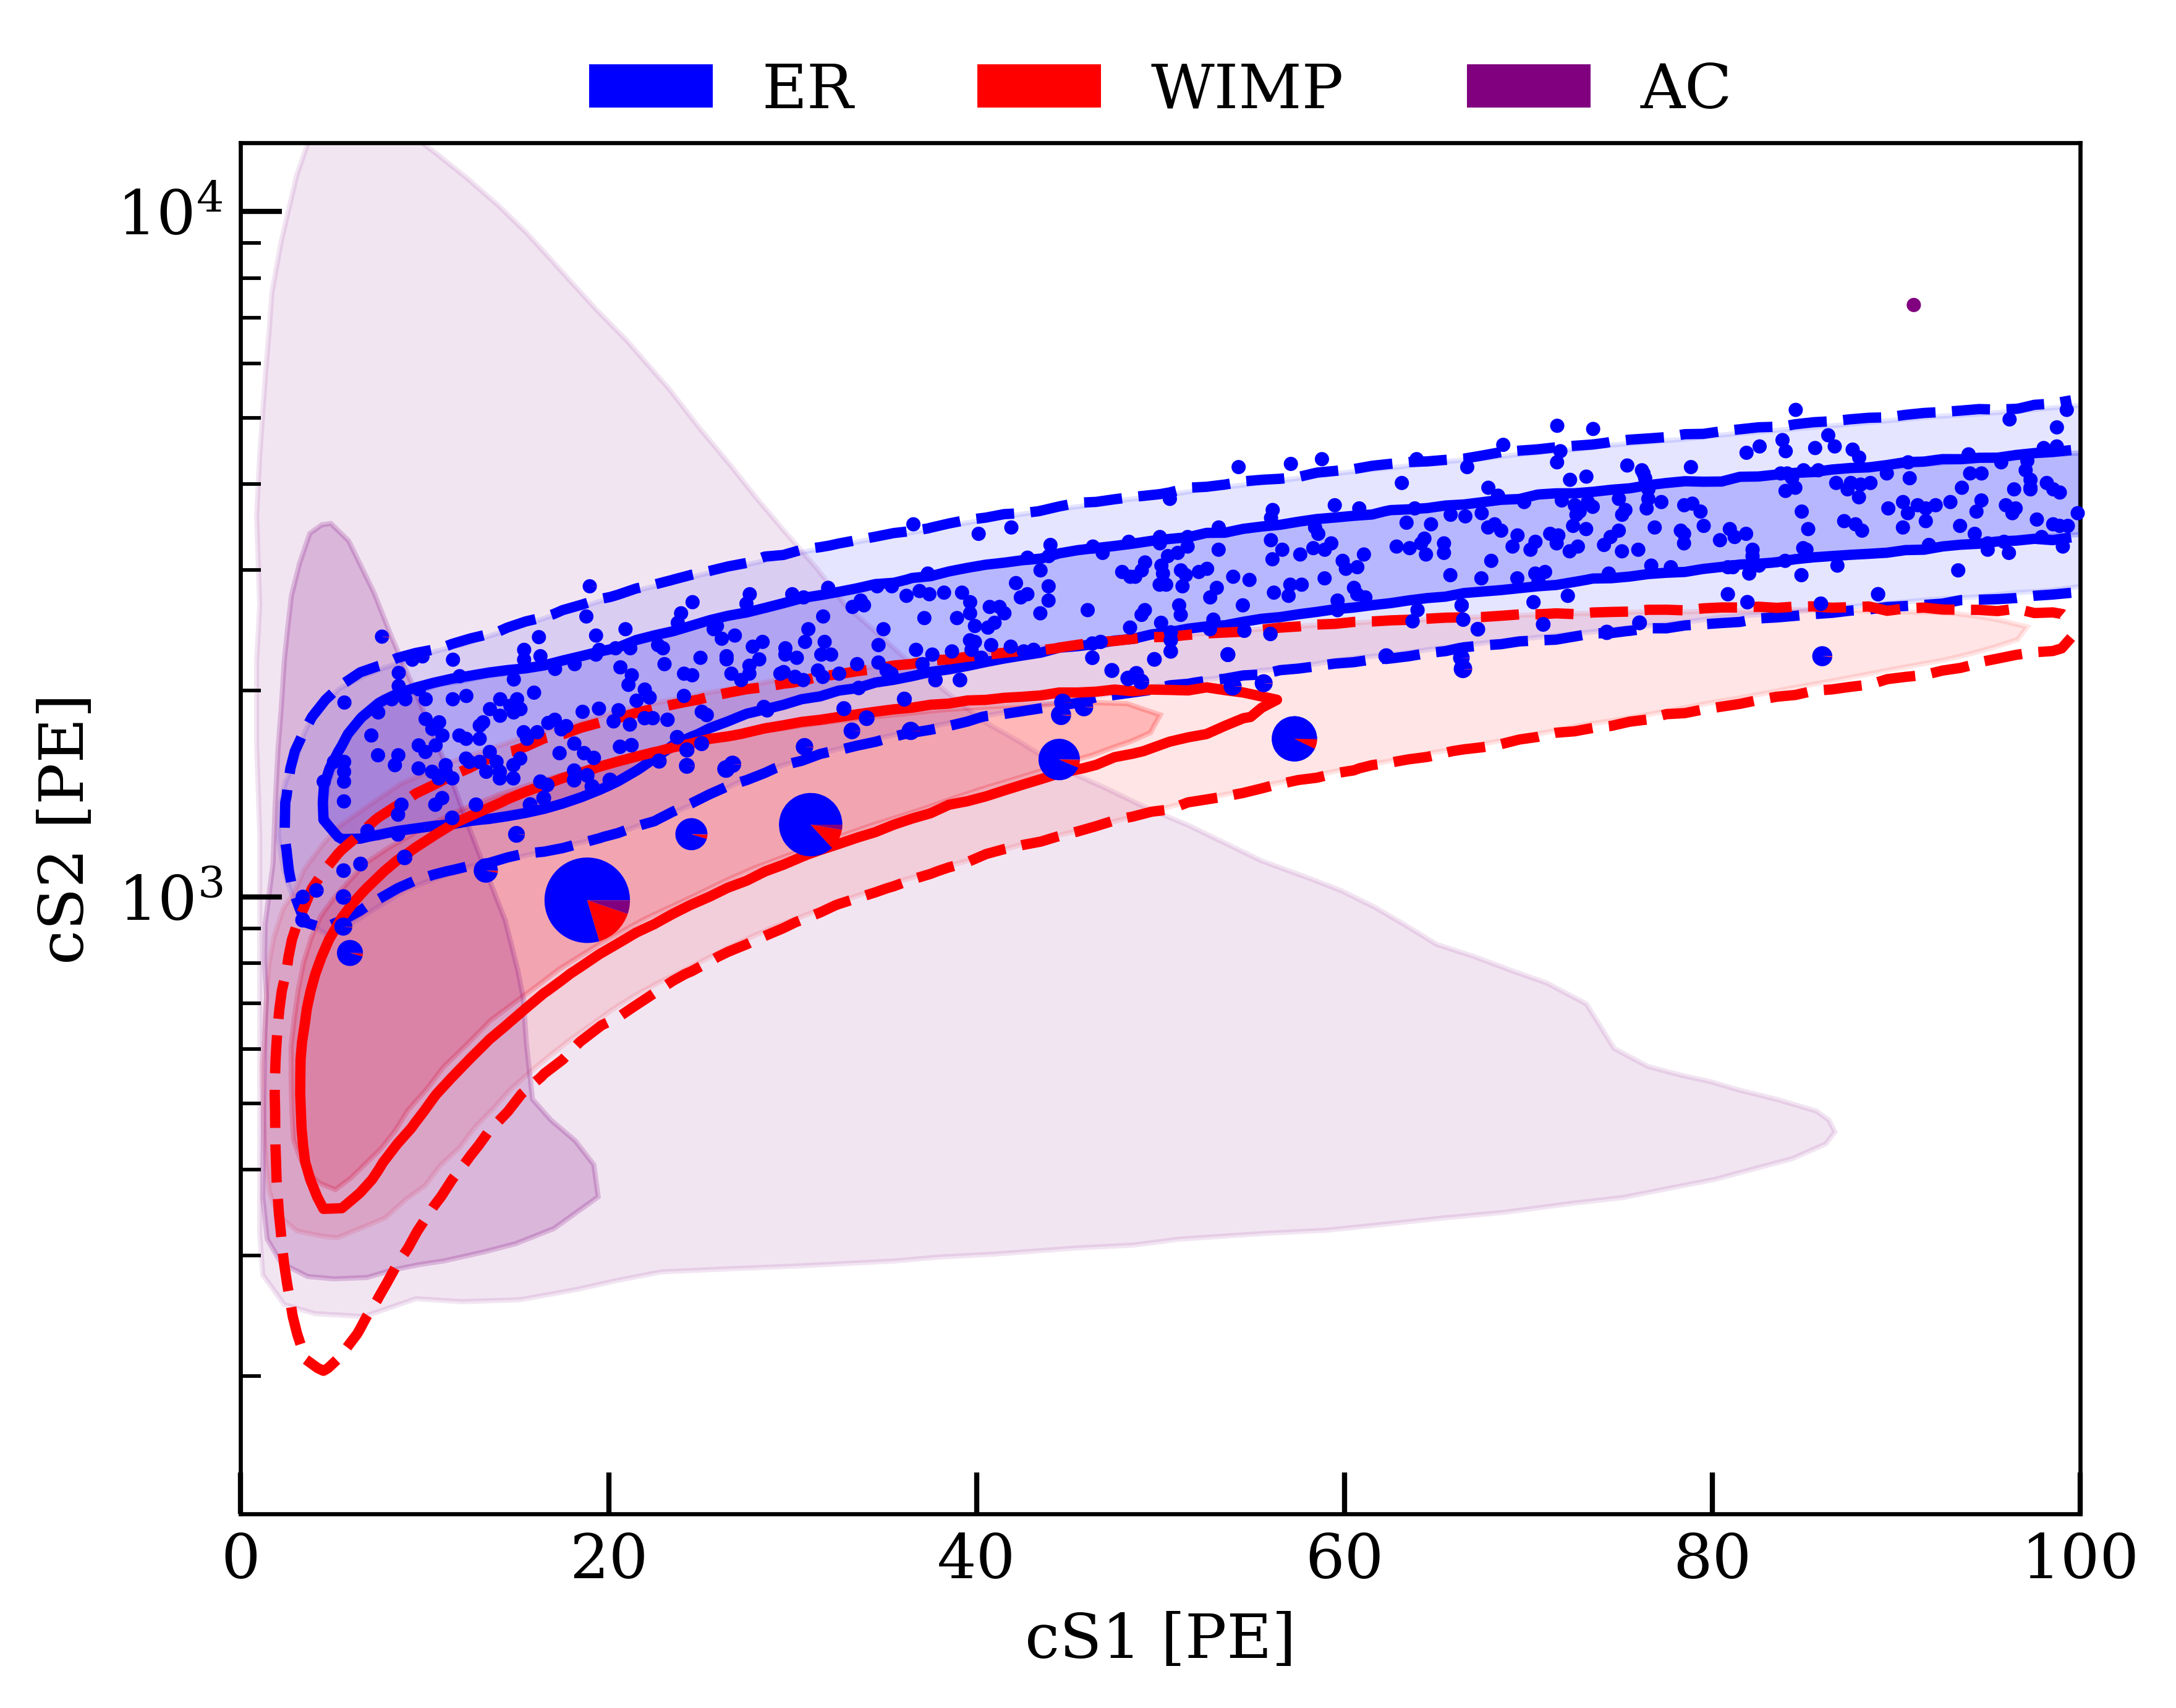

In [130]:
plot_contours_and_pies(
    xenonnt_sr01_st,
    {
        "experiment_name": "xenonnt_sr1a",
        "signal_parameter_value": 200,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "component_name": "er",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "bkg_to_include": ["er_flat", "tritium", "ar37"],
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr1a_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1a_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "signal",
                "component_name": "wimp",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "color": "red",
                "one_sigma_contour_fname": "xenonnt_sr1b_wimp_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_wimp_2sigma.csv",
                "log10_contour": False,
                "label": "WIMP",
            },
            {
                "type": "bkg",
                "component_name": "xenonnt_sr1_ac",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr1b_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 6,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 4,
            },
        },
    },
)
plt.savefig("../plots/xenonnt_sr1a_cs1_cs2_contours.png", dpi=600, bbox_inches="tight")

True
True
True
True
True
True


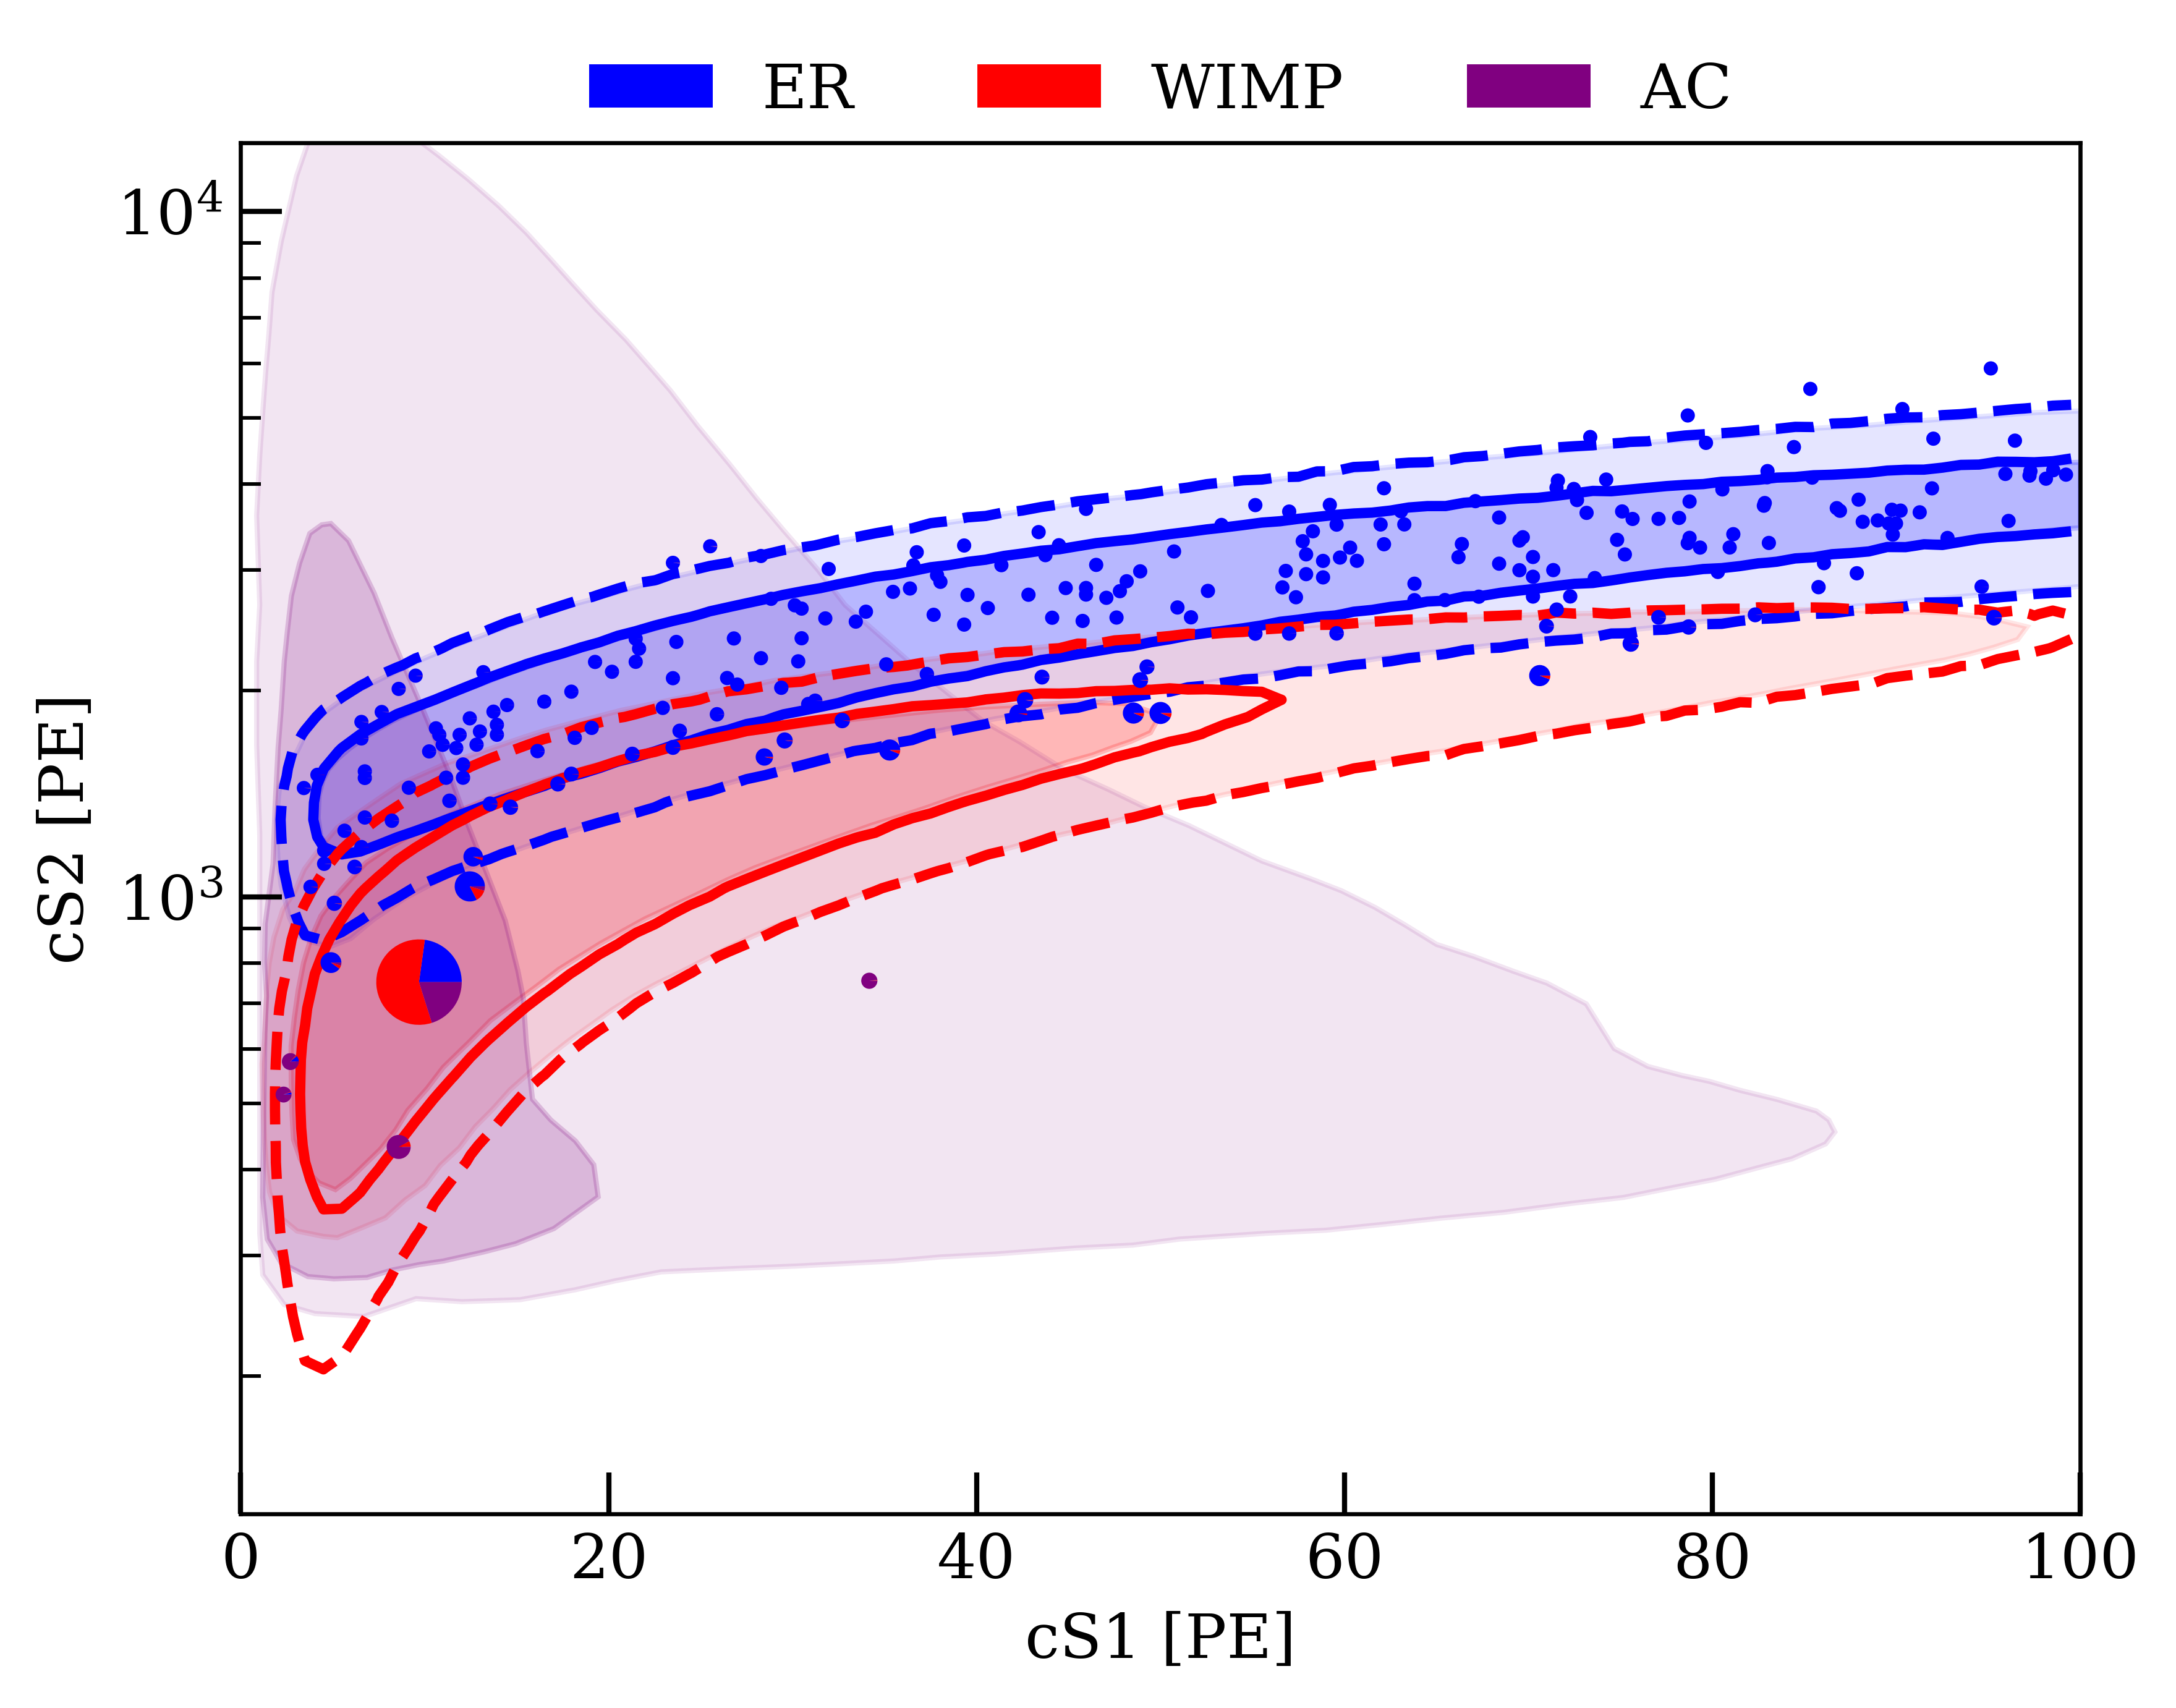

In [116]:
plot_contours_and_pies(
    xenonnt_sr01_st,
    {
        "experiment_name": "xenonnt_sr1b",
        "signal_parameter_value": 200,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "component_name": "er",
                "bkg_to_include": ["er_flat", "tritium"],
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr1b_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "signal",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "component_name": "wimp",
                "color": "red",
                "one_sigma_contour_fname": "xenonnt_sr1b_wimp_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_wimp_2sigma.csv",
                "log10_contour": False,
                "label": "WIMP",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "component_name": "xenonnt_sr1_ac",
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr1b_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 6,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 4,
            },
        },
    },
)
# data = xenonnt_sr01_st.experiment_instances[2].get_data()
# plt.yscale("log")
# plt.scatter(data["cs1"], data["cs2"], s=1, c="k")
# plt.xlim(0, 100)
# plt.ylim(10**2.1, 10**4.1)

# plt.axhline(400, color="k", linestyle="--", alpha=0.2)
# plt.xlabel("cS1 [PE]")
# plt.ylabel("cS2 [PE]")
# plt.savefig("../plots/xenonnt_sr1b_cs1_cs2_contours.png", dpi=600, bbox_inches="tight")

In [16]:
xenonnt_sr01_st.print_best_fit(200)

xenonnt_sr0
                   Nominal   Best fit
er                     134   135 ± 12
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
ac               4.3 ± 0.9  4.3 ± 0.8
surface             14 ± 3     12 ± 2
Signal best fit: 1.1672102359641965

xenonnt_sr1a
                     Nominal     Best fit
er_flat             430 ± 30     460 ± 30
tritium                   62      20 ± 30
ar37                  58 ± 6       53 ± 5
xenonnt_neutron  0.47 ± 0.19  0.47 ± 0.18
xenonnt_sr1_ac   2.12 ± 0.18  2.10 ± 0.18
Signal best fit: 0.7822156653556871

xenonnt_sr1b
                   Nominal   Best fit
er_flat           151 ± 11   156 ± 10
tritium                101    71 ± 17
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
xenonnt_sr1_ac   3.8 ± 0.3  3.8 ± 0.3
Signal best fit: 1.4082230972394427



Running inference: 100%|██████████| 90/90 [15:51<00:00, 10.58s/it]


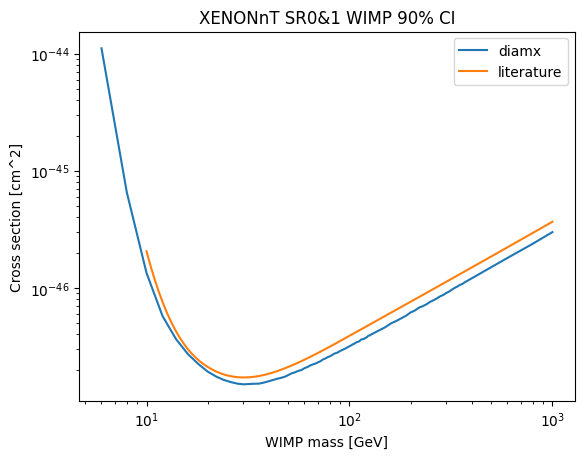

In [17]:
xenonnt_sr01_st.run_inference(output_file_name="xenonnt_sr1_wimp_ci_full_roi.csv")
ci = np.loadtxt("./diamx_output/xenonnt_sr1_wimp_ci_full_roi.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr1_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0&1 WIMP 90% CI")
plt.savefig("../plots/xenonnt_sr1_wimp_ci_full_roi.png", dpi=600)
# plt.show()

Generating background templates for xenonnt_sr0: 100%|██████████| 4/4 [00:07<00:00,  1.85s/it]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating background templates for xenonnt_sr1a: 100%|██████████| 5/5 [00:31<00:00,  6.35s/it]
Generating shaped background templates for xenonnt_sr1a: 0it [00:00, ?it/s]
Generating background templates for xenonnt_sr1b: 100%|██████████| 4/4 [00:20<00:00,  5.19s/it]
Generating shaped background templates for xenonnt_sr1b: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr1b: 100%|██████████| 90/90 [11:03<00:00,  7.37s/it]


xenonnt_sr0
                   Nominal   Best fit
er                     134   135 ± 12
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
ac                       1  0.0 ± 0.7
surface                  1  3.0 ± 1.7
Signal best fit: 1.819508807465924

xenonnt_sr1a
                     Nominal     Best fit
er_flat             430 ± 30     460 ± 30
tritium                   62      20 ± 30
ar37                  58 ± 6       53 ± 5
xenonnt_neutron  0.47 ± 0.19  0.47 ± 0.19
xenonnt_sr1_ac   2.12 ± 0.18  2.11 ± 0.18
Signal best fit: 1.2193589882946738

xenonnt_sr1b
                   Nominal   Best fit
er_flat           151 ± 11   156 ± 10
tritium                101    70 ± 17
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
xenonnt_sr1_ac   3.8 ± 0.3  3.8 ± 0.3
Signal best fit: 2.1952123528007723



Running inference: 100%|██████████| 90/90 [16:38<00:00, 11.10s/it]


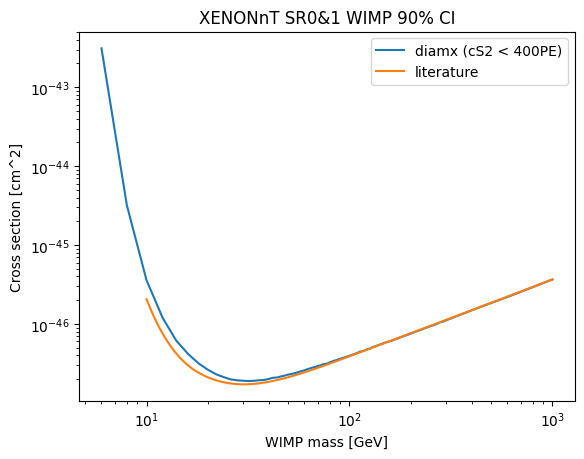

In [18]:
xenonnt_sr01_st_400PE = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_and_1_wimp_config.json"),
)
xenonnt_sr01_st_400PE.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr01_st_400PE.register_experiment(diamx.experiments.XENONnTSR1a)
xenonnt_sr01_st_400PE.register_experiment(diamx.experiments.XENONnTSR1b)
xenonnt_sr01_st_400PE.generate_templates()
xenonnt_sr01_st_400PE.print_best_fit(200)
xenonnt_sr01_st_400PE.run_inference(output_file_name="xenonnt_sr1_wimp_ci_400PE.csv")
ci_400PE = np.loadtxt("./diamx_output/xenonnt_sr1_wimp_ci_400PE.csv", delimiter=",")
plt.plot(ci_400PE[:, 0], ci_400PE[:, 2] * 1e-44, label="diamx (cS2 < 400PE)")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr1_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0&1 WIMP 90% CI")

plt.savefig("../plots/xenonnt_sr1_wimp_ci_400PE.png", dpi=600, bbox_inches="tight")

## 4. LZ WS2024

arXiv:2410.17036

In [133]:
lz_ws2024_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "lz_ws2024_wimp_config.json"),
)
lz_ws2024_st.register_experiment(diamx.experiments.LZWS2022)
lz_ws2024_st.register_experiment(diamx.experiments.LZWS2024)
# lz_ws2024_st.generate_templates()
lz_ws2024_st.prepare()

True
True
True
True


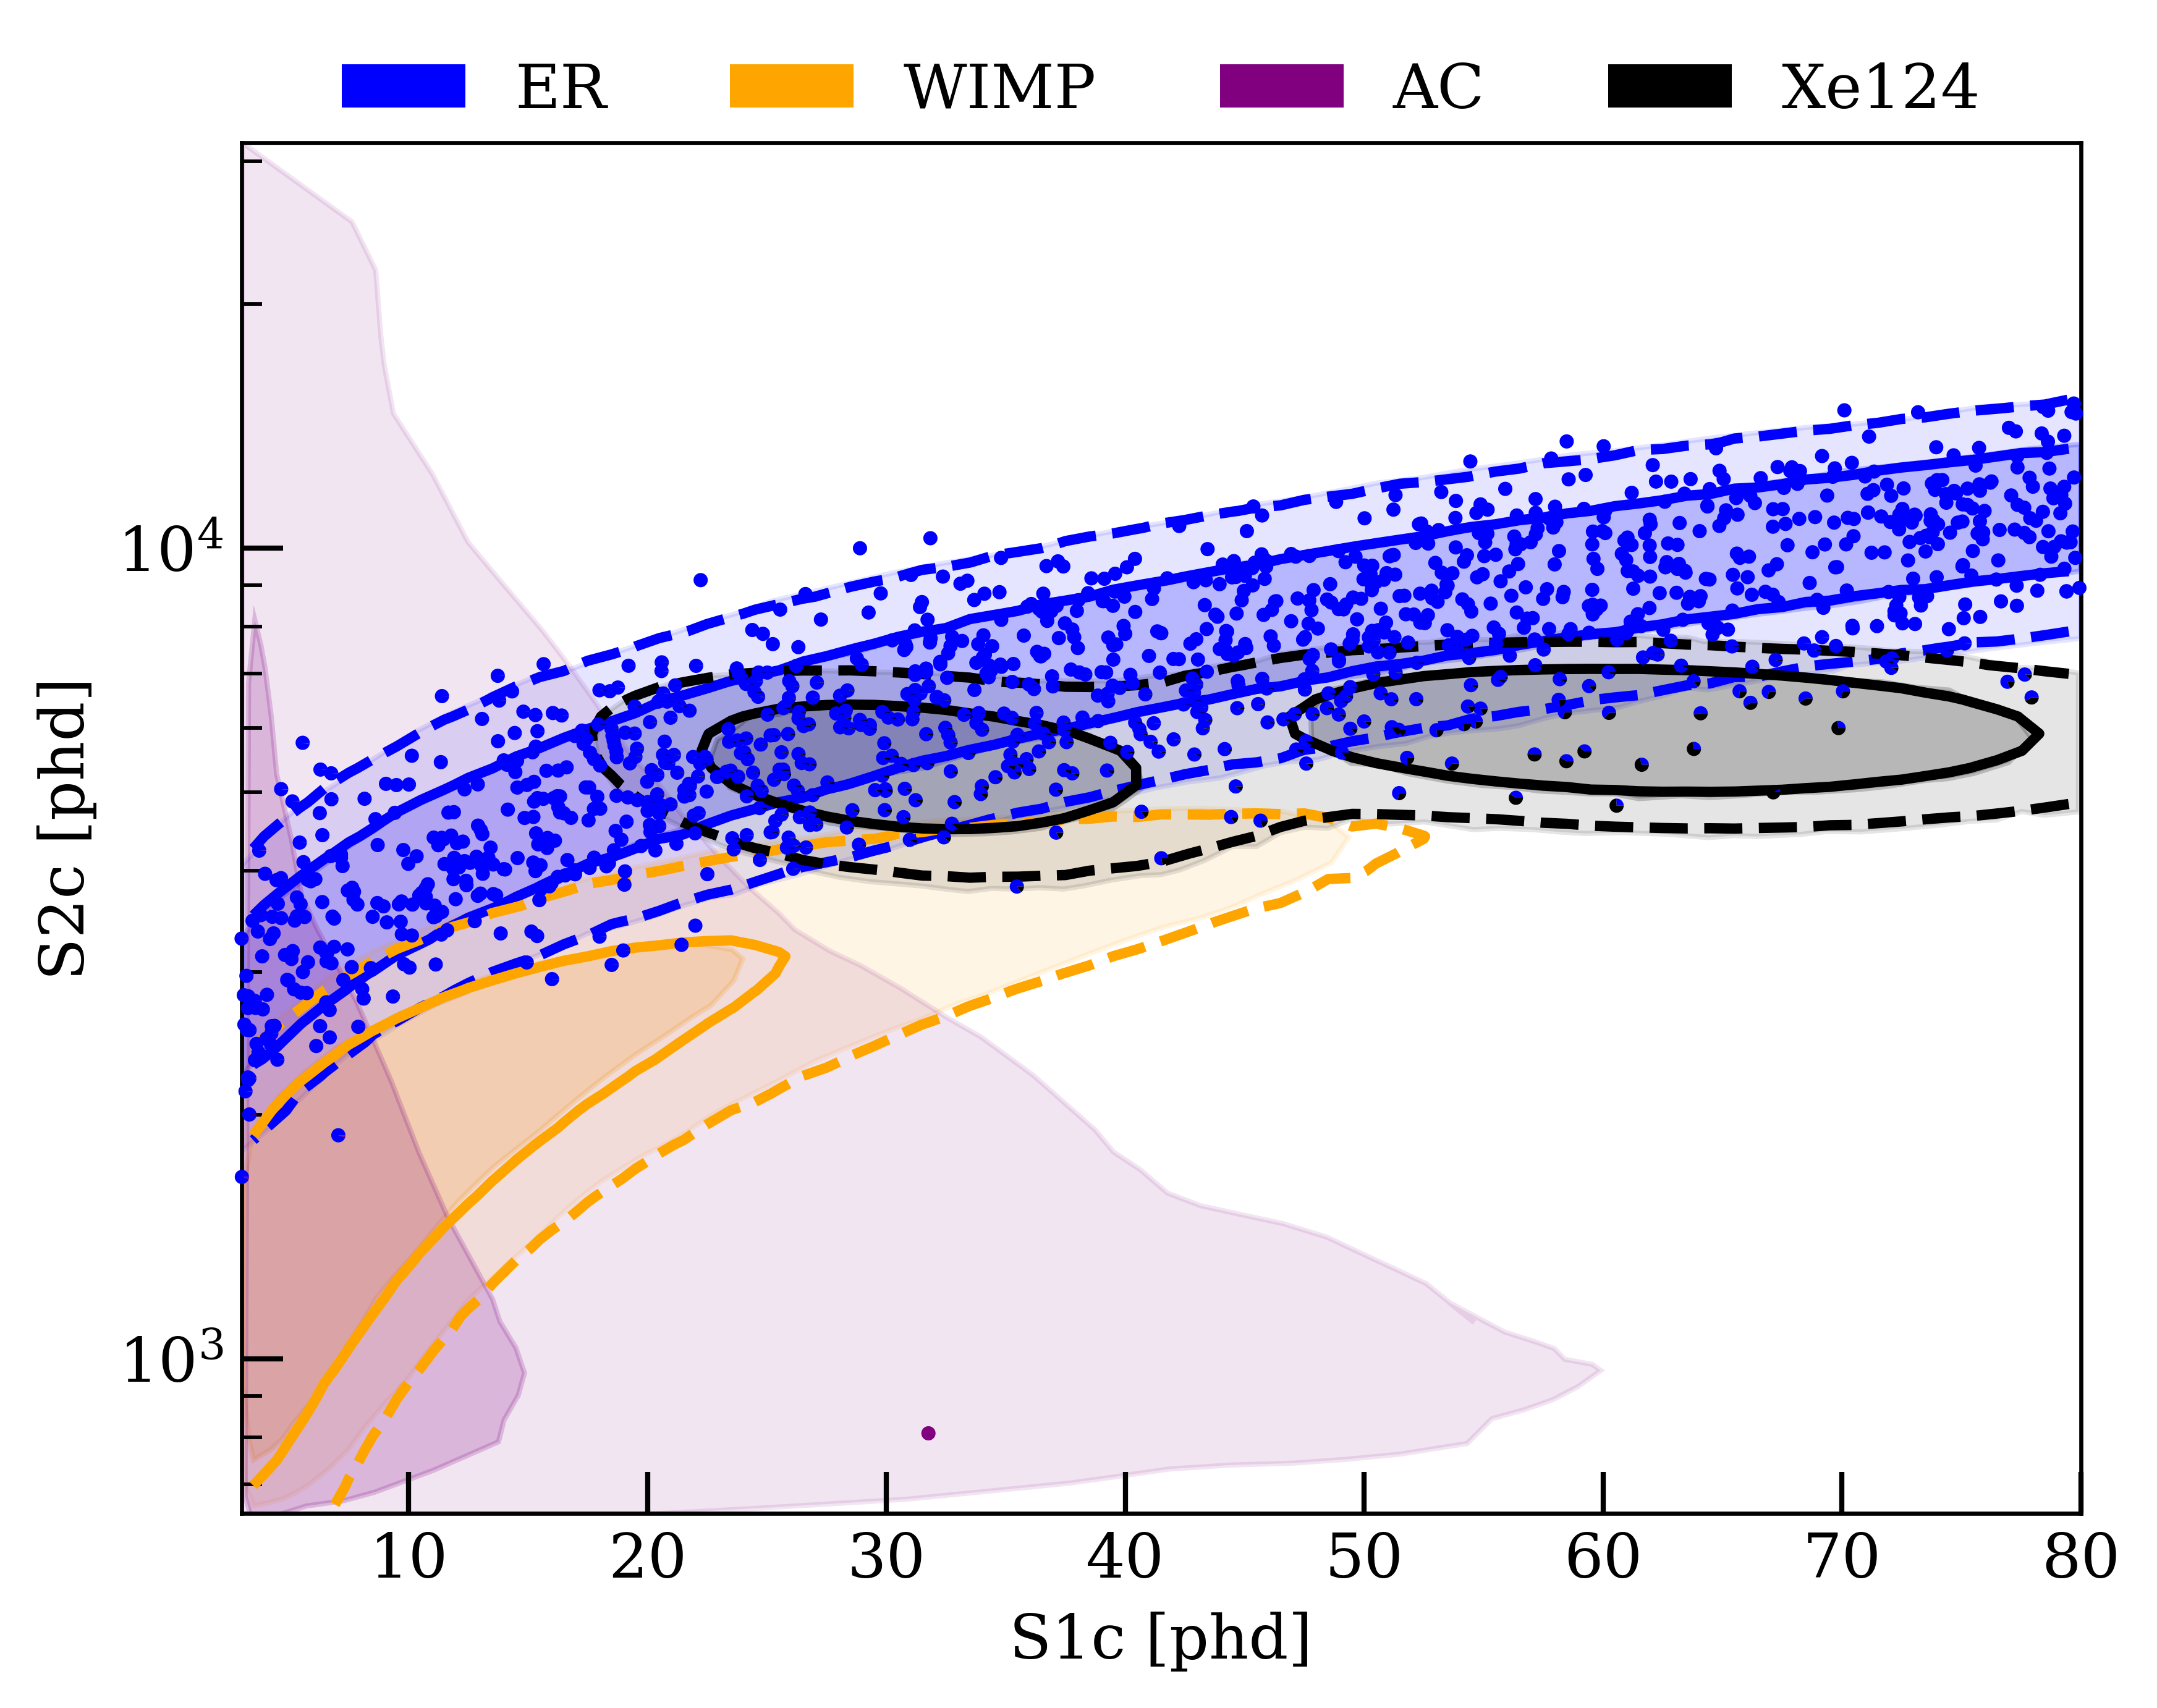

In [129]:
plot_contours_and_pies(
    lz_ws2024_st,
    {
        "experiment_name": "lz_ws2024",
        "signal_parameter_value": 40,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "component_name": "er",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "bkg_to_include": [
                    "pb214",
                    "kr85_ar39_detgamma",
                    "solar_neutrino_er",
                    "pb212_po218",
                    "tritium_c14",
                    "xe136",
                    "xe127_xe125",
                ],
                "color": "blue",
                "one_sigma_contour_fname": "lz_ws2024_er_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2024_er_2sigma.csv",
                "log10_contour": True,
                "label": "ER",
            },
            {
                "type": "signal",
                "component_name": "wimp",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "color": "orange",
                "one_sigma_contour_fname": "lz_ws2024_wimp_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2024_wimp_2sigma.csv",
                "log10_contour": True,
                "label": "WIMP",
            },
            {
                "type": "bkg",
                "component_name": "ac",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "color": "purple",
                "one_sigma_contour_fname": "lz_ws2024_ac_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2024_ac_2sigma.csv",
                "log10_contour": True,
                "label": "AC",
            },
            {
                "type": "shaped_bkg",
                "component_name": "xe124",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "color": "k",
                "shape_parameter_value": [0.69],
                "one_sigma_contour_fname": [
                    "lz_ws2024_xe124_1sigma_left.csv",
                    "lz_ws2024_xe124_1sigma_right.csv",
                ],
                "two_sigma_contour_fname": "lz_ws2024_xe124_2sigma.csv",
                "log10_contour": True,
                "label": r"Xe124",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["s1c", "s2c"],
            "axis_labels": ["S1c [phd]", "S2c [phd]"],
            "axis_limits": [[3, 80], [645, 10**4.5]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 1,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 4,
            },
        },
    },
)
plt.savefig("../plots/lz_ws2024_s1c_s2c_contours.png", dpi=600, bbox_inches="tight")

In [21]:
lz_ws2024_st.print_best_fit(40, disable_rounding=True, stabilize_fit=False)

lz_ws2022
                           Nominal                                Best fit
beta                  215.0 ± 36.0  224.4820769486279 ± 16.166459574249096
neutrino                27.1 ± 1.6  27.118088915733587 ± 1.598472271692544
xe127                    9.2 ± 0.8  9.245482499040357 ± 0.7932713386712608
xe124     5.0 ± 1.3999999999999997  5.313250637931055 ± 1.3755772814875216
xe136                   15.1 ± 2.4    15.13940536087391 ± 2.38943440871272
ar37                          50.0   50.25557457262034 ± 9.079458393271777
Signal best fit: 1.0438637239888257e-06

lz_ws2024
                                    Nominal  \
pb214                          743.0 ± 88.0   
kr85_ar39_detgamma             162.0 ± 22.0   
solar_neutrino_er               102.0 ± 6.0   
pb212_po218                      62.7 ± 7.5   
tritium_c14         58.29999999999999 ± 3.3   
xe136                            55.6 ± 8.3   
xe127_xe125                       3.2 ± 0.6   
ac                                2.8 

Running inference: 100%|██████████| 67/67 [13:57<00:00, 12.50s/it]


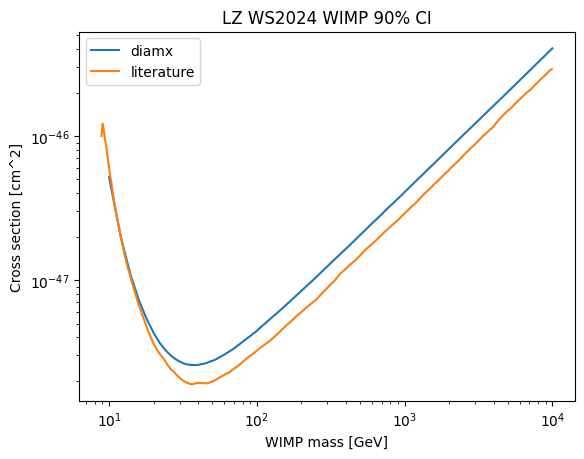

In [22]:
lz_ws2024_st.run_inference(output_file_name="lz_ws2024_wimp_ci.csv")
ci = np.loadtxt("./diamx_output/lz_ws2024_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/lz_ws2024_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("LZ WS2024 WIMP 90% CI")
plt.savefig("../plots/lz_ws2024_wimp_ci.png", dpi=600)
# plt.show()